# 03 · Econometric Market Value Model

## Market Value Dynamics and Inefficiency in European Football Transfers

Este notebook construye el **modelo econométrico final** del TFM para estimar el valor de mercado esperado de jugadores de fútbol profesional europeo y derivar un **Inefficiency Score** basado en residuos.

El objetivo analítico es estimar:

\[
\log(\text{Market Value}_{i,t}) = f(X_{i,t}, \text{League FE}, \text{Season FE}, \text{Position FE}) + \varepsilon_{i,t}
\]

donde la unidad de análisis es el par **jugador–temporada**.

El modelo se utiliza como componente interpretable del sistema de scouting cuantitativo, permitiendo comparar el valor observado de mercado frente al valor esperado estimado por el modelo.

## 1. Objetivo del notebook

Este notebook tiene cinco objetivos principales:

1. Construir un modelo OLS robusto para explicar el valor de mercado de los jugadores.
2. Incorporar efectos fijos de liga, temporada y posición para controlar heterogeneidad estructural.
3. Evaluar el modelo desde una perspectiva econométrica y predictiva.
4. Diagnosticar problemas de multicolinealidad, escala y residuos.
5. Construir rankings de jugadores potencialmente infravalorados y sobrevalorados mediante un **Inefficiency Score**.

Desde el punto de vista de negocio, el modelo sirve como una primera capa cuantitativa para priorizar jugadores que merecen análisis de scouting adicional.

## 2. Justificación metodológica

### 2.1 Por qué OLS

Se utiliza una regresión lineal por Mínimos Cuadrados Ordinarios como modelo econométrico principal por tres razones:

- **Interpretabilidad:** permite analizar la dirección y magnitud de la relación entre rendimiento deportivo, edad, minutos y valor de mercado.
- **Trazabilidad:** facilita explicar al usuario de negocio por qué un jugador aparece como infravalorado o sobrevalorado.
- **Baseline robusto:** actúa como referencia econométrica antes de incorporar modelos no lineales de machine learning.

### 2.2 Por qué transformar el target en logaritmo

El valor de mercado presenta una distribución fuertemente asimétrica, con pocos jugadores extremadamente caros y muchos jugadores de menor valor. Por ello se modeliza:

\[
y = \log(\text{market\_value\_eur})
\]

Esta transformación reduce la influencia de valores extremos, mejora la estabilidad del modelo y permite interpretar los coeficientes de forma aproximadamente porcentual.

### 2.3 Por qué fixed effects

El mercado no valora igual a un jugador en todas las ligas, temporadas y posiciones. Los efectos fijos permiten controlar diferencias sistemáticas entre contextos:

- **League FE:** diferencias de exposición, poder económico, visibilidad internacional y eficiencia relativa del mercado.
- **Season FE:** inflación del mercado, shocks macroeconómicos y cambios temporales del entorno futbolístico.
- **Position FE:** distinta estructura de valoración entre porteros, defensas, centrocampistas y atacantes.

### 2.4 Por qué errores robustos HC3

El valor de mercado suele presentar heterocedasticidad: el error esperado no es constante entre jugadores baratos y jugadores de élite. Por ello se estiman errores estándar robustos HC3, adecuados para mejorar la inferencia en presencia de heterocedasticidad y observaciones influyentes.

In [1]:
# ============================================================
# 0. Imports y configuración
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

In [2]:
# ============================================================
# 1. Rutas del proyecto
# ============================================================

# Este notebook está pensado para vivir dentro de notebooks/.
# Si se ejecuta desde otra ubicación, ajusta PROJECT_ROOT manualmente.

NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "player_season_modeling.parquet"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")

PROJECT_ROOT: c:\Users\manue\Projects\market-value-football-tfm
DATA_PATH: c:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling.parquet
OUTPUT_DIR: c:\Users\manue\Projects\market-value-football-tfm\reports\tables
FIGURES_DIR: c:\Users\manue\Projects\market-value-football-tfm\reports\figures


## 3. Carga del dataset

Se carga el dataset final de modelado, construido a nivel **jugador–temporada**. Este dataset debe contener únicamente observaciones con valor de mercado disponible y variables explicativas válidas.

In [3]:
# ============================================================
# 2. Carga de datos
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se ha encontrado el dataset esperado: {DATA_PATH}. "
        "Verifica que existe data/processed/player_season_modeling.parquet "
        "o ajusta DATA_PATH."
    )

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado correctamente")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Dataset cargado correctamente
Filas: 1,012
Columnas: 50


,player_name_fbref,normalized_name,season,season_start_year_fbref,league,club,position,age_fbref,minutes_played,matches,goals,assists,goals_per90,assists_per90,g_a_per90,shots_per90,progressive_passes_per90,progressive_carries_per90,tackles_per90,interceptions_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,position_group,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age
0,Aaron Ramsdale,aaron ramsdale,2020-2021,2020,Premier League,Sheffield United,GK,22.0000,3420,38,0,0,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,aaron ramsdale,"427,568.0000",Aaron Ramsdale,"2,020.0000",2021-05-28,"12,000,000.0000",16.3004,"12,500,000.0000","28,000,000.0000",1.3333,0.8473,23.0000,1998-05-14,England,Goalkeeper,Goalkeeper,GK,right,190.0000,Sheffield United,350.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.0000,100.0000,True,2020,23.0000
1,Illan Meslier,illan meslier,2021-2022,2021,Premier League,Leeds United,GK,21.0000,3384,38,0,0,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,illan meslier,"542,586.0000",Illan Meslier,"2,021.0000",2022-06-15,"20,000,000.0000",16.8112,"20,000,000.0000","20,000,000.0000",0.0000,0.0000,22.3000,2000-03-02,France,Goalkeeper,Goalkeeper,GK,left,197.0000,Leeds United,399.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.3000,100.0000,True,2021,22.3000
2,Marc Guéhi,marc guehi,2022-2023,2022,Premier League,Crystal Palace,DF,22.0000,3329,37,1,0,0.0270,0.0000,0.0270,NaN,NaN,NaN,NaN,NaN,marc guehi,"392,757.0000",Marc Guéhi,"2,022.0000",2023-06-20,"35,000,000.0000",17.3709,"32,000,000.0000","38,000,000.0000",0.0857,0.0822,22.9000,2000-07-13,England,Defender,Centre-Back,DEF,right,182.0000,Crystal Palace,873.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.9000,100.0000,True,2022,22.9000
3,Marc Guéhi,marc guehi,2021-2022,2021,Premier League,Crystal Palace,DF,21.0000,3222,36,2,1,0.0559,0.0279,0.0838,NaN,NaN,NaN,NaN,NaN,marc guehi,"392,757.0000",Marc Guéhi,"2,021.0000",2022-06-15,"32,000,000.0000",17.2812,"10,000,000.0000","35,000,000.0000",0.0938,0.0896,21.9000,2000-07-13,England,Defender,Centre-Back,DEF,right,182.0000,Crystal Palace,873.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.9000,100.0000,True,2021,21.9000
4,Illan Meslier,illan meslier,2020-2021,2020,Premier League,Leeds United,GK,20.0000,3150,35,0,0,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,illan meslier,"542,586.0000",Illan Meslier,"2,020.0000",2021-06-08,"20,000,000.0000",16.8112,"4,500,000.0000","20,000,000.0000",0.0000,0.0000,21.3000,2000-03-02,France,Goalkeeper,Goalkeeper,GK,left,197.0000,Leeds United,399.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.3000,100.0000,True,2020,21.3000


In [4]:
# Vista rápida de columnas disponibles
sorted(df.columns.tolist())

['age',
 'age_diff',
 'age_fbref',
 'age_tm',
 'assists',
 'assists_per90',
 'club',
 'club_score',
 'competition_id_tm',
 'current_club_id_tm',
 'current_club_name_tm',
 'date_of_birth',
 'delta_log_market_value_1y',
 'foot',
 'g_a_per90',
 'goals',
 'goals_per90',
 'height_in_cm',
 'interceptions_per90',
 'league',
 'log_market_value_eur',
 'market_value_eur',
 'market_value_growth_1y',
 'market_value_next_eur',
 'market_value_prev_eur',
 'matches',
 'matching_confidence',
 'matching_method',
 'matching_status',
 'minutes_played',
 'nationality',
 'normalized_name',
 'player_id_tm',
 'player_name_fbref',
 'player_name_norm',
 'player_name_tm',
 'position',
 'position_group',
 'position_tm',
 'progressive_carries_per90',
 'progressive_passes_per90',
 'season',
 'season_start_year',
 'season_start_year_fbref',
 'season_start_year_tm',
 'shots_per90',
 'source',
 'sub_position_tm',
 'tackles_per90',
 'valuation_date']

## 4. Validación mínima del dataset

Antes de modelizar, se comprueba que existen las variables mínimas necesarias para estimar el modelo econométrico final:

- Target: `log_market_value_eur`
- Variables numéricas: `minutes_played`, `goals_per90`, `assists_per90`, `age`
- Efectos fijos: `league`, `season`, `position_group`

También se mantienen variables auxiliares para interpretar los rankings finales.

In [5]:
# ============================================================
# 3. Definición de variables
# ============================================================

TARGET = "log_market_value_eur"

BASE_FEATURES = [
    "minutes_played",
    "goals_per90",
    "assists_per90",
    "age",
]

FIXED_EFFECTS = [
    "league",
    "season",
    "position_group",
]

AUXILIARY_COLUMNS_CANDIDATES = [
    "player_id",
    "player_name",
    "club",
    "league",
    "season",
    "position_group",
    "age",
    "market_value_eur",
    "matching_method",
    "matching_confidence",
    "age_diff",
    "club_score",
]

required_columns = [TARGET] + BASE_FEATURES + FIXED_EFFECTS
missing_required = [col for col in required_columns if col not in df.columns]

if missing_required:
    raise KeyError(
        "Faltan columnas obligatorias para el modelo: "
        + ", ".join(missing_required)
    )

auxiliary_columns = [col for col in AUXILIARY_COLUMNS_CANDIDATES if col in df.columns]

print("Variables obligatorias disponibles.")
print("Columnas auxiliares disponibles:")
print(auxiliary_columns)

Variables obligatorias disponibles.
Columnas auxiliares disponibles:
['club', 'league', 'season', 'position_group', 'age', 'market_value_eur', 'matching_method', 'matching_confidence', 'age_diff', 'club_score']


In [6]:
# ============================================================
# 4. Preparación del dataset de modelado
# ============================================================

selected_columns = list(dict.fromkeys(required_columns + auxiliary_columns))
model_df = df[selected_columns].copy()

# Conversión explícita de variables numéricas
for col in [TARGET] + BASE_FEATURES:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Eliminación de observaciones sin información mínima para el modelo
initial_rows = len(model_df)
model_df = model_df.dropna(subset=required_columns).copy()
final_rows = len(model_df)

print(f"Filas iniciales: {initial_rows:,}")
print(f"Filas tras dropna en variables obligatorias: {final_rows:,}")
print(f"Filas eliminadas: {initial_rows - final_rows:,}")

model_df.head()

Filas iniciales: 1,012
Filas tras dropna en variables obligatorias: 1,012
Filas eliminadas: 0


,log_market_value_eur,minutes_played,goals_per90,assists_per90,age,league,season,position_group,club,market_value_eur,matching_method,matching_confidence,age_diff,club_score
0,16.3004,3420,0.0000,0.0000,23.0000,Premier League,2020-2021,GK,Sheffield United,"12,000,000.0000",exact_age_club_validated,1.0000,1.0000,100.0000
1,16.8112,3384,0.0000,0.0000,22.3000,Premier League,2021-2022,GK,Leeds United,"20,000,000.0000",exact_age_club_validated,1.0000,1.3000,100.0000
2,17.3709,3329,0.0270,0.0000,22.9000,Premier League,2022-2023,DEF,Crystal Palace,"35,000,000.0000",exact_age_club_validated,1.0000,0.9000,100.0000
3,17.2812,3222,0.0559,0.0279,21.9000,Premier League,2021-2022,DEF,Crystal Palace,"32,000,000.0000",exact_age_club_validated,1.0000,0.9000,100.0000
4,16.8112,3150,0.0000,0.0000,21.3000,Premier League,2020-2021,GK,Leeds United,"20,000,000.0000",exact_age_club_validated,1.0000,1.3000,100.0000


## 5. Análisis descriptivo previo al modelo

Este bloque permite comprobar la escala y dispersión de las variables utilizadas en el modelo. Es especialmente importante en este proyecto porque el mercado de fichajes combina jugadores de muy distinto nivel, edad, exposición mediática y contexto competitivo.

In [7]:
# Estadísticos descriptivos de variables principales
model_df[[TARGET] + BASE_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
log_market_value_eur,"1,012.0000",15.6132,1.3432,13.1224,14.5087,15.6073,16.6560,19.0085
minutes_played,"1,012.0000","1,383.0158",769.1431,301.0000,727.7500,"1,252.0000","1,924.0000","3,420.0000"
goals_per90,"1,012.0000",0.1381,0.1887,0.0000,0.0000,0.0753,0.2027,1.9033
assists_per90,"1,012.0000",0.0949,0.1166,0.0000,0.0000,0.0633,0.1468,0.9375
age,"1,012.0000",21.4566,1.1456,18.0000,20.9000,21.5000,22.3000,23.0000


In [8]:
# Distribución por liga, temporada y posición
for col in FIXED_EFFECTS:
    print("=" * 80)
    print(col)
    print(model_df[col].value_counts(dropna=False).head(20))

league
league
Bundesliga        159
Serie A           158
Eredivisie        153
Premier League    143
Ligue 1           140
LaLiga            130
Liga Portugal     129
Name: count, dtype: int64
season
season
2023-2024    275
2020-2021    263
2021-2022    244
2022-2023    230
Name: count, dtype: int64
position_group
position_group
ATT    336
MID    325
DEF    321
GK      30
Name: count, dtype: int64


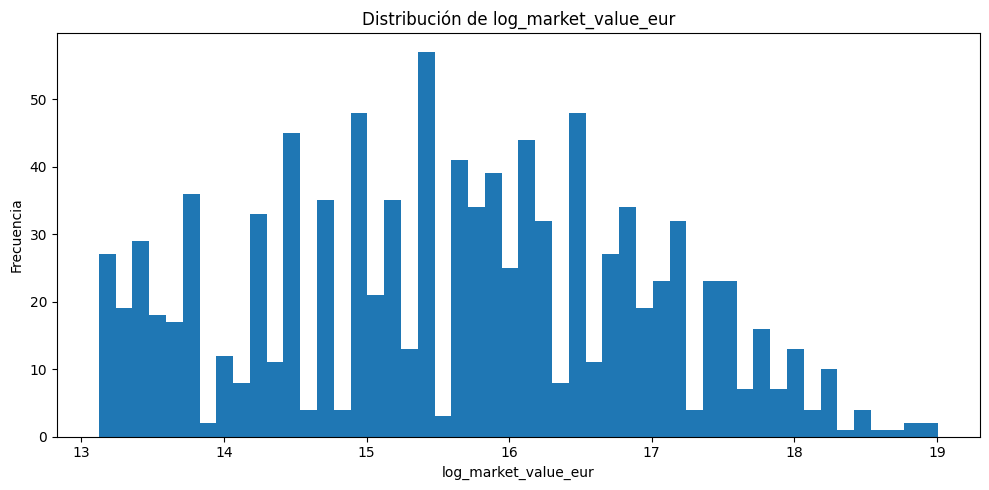

In [9]:
# Distribución del target logarítmico
plt.figure(figsize=(10, 5))
plt.hist(model_df[TARGET], bins=50)
plt.title("Distribución de log_market_value_eur")
plt.xlabel("log_market_value_eur")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_target_log_distribution.png", dpi=150)
plt.show()

## 6. Construcción de efectos fijos

Los efectos fijos se implementan mediante variables dummy con `drop_first=True`, evitando la trampa de las variables ficticias. La categoría omitida actúa como grupo de referencia.

Formalmente, el modelo estimado es:

\[
\log(MV_{i,t}) = \beta_0 + \beta_1 Minutes_{i,t} + \beta_2 Goals90_{i,t} + \beta_3 Assists90_{i,t} + \beta_4 Age_{i,t} + \gamma_l + \delta_t + \theta_p + \varepsilon_{i,t}
\]

donde:

- \(\gamma_l\) representa efectos fijos de liga.
- \(\delta_t\) representa efectos fijos de temporada.
- \(\theta_p\) representa efectos fijos de posición.

In [10]:
# ============================================================
# 5. Matriz de diseño con fixed effects
# ============================================================

X_base = model_df[BASE_FEATURES + FIXED_EFFECTS].copy()

X_encoded = pd.get_dummies(
    X_base,
    columns=FIXED_EFFECTS,
    drop_first=True,
    dtype=float,
)

X = sm.add_constant(X_encoded, has_constant="add")
y = model_df[TARGET].astype(float)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
X.head()

X shape: (1012, 17)
y shape: (1012,)


,const,minutes_played,goals_per90,assists_per90,age,league_Eredivisie,league_LaLiga,league_Liga Portugal,league_Ligue 1,league_Premier League,league_Serie A,season_2021-2022,season_2022-2023,season_2023-2024,position_group_DEF,position_group_GK,position_group_MID
0,1.0000,3420,0.0000,0.0000,23.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
1,1.0000,3384,0.0000,0.0000,22.3000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
2,1.0000,3329,0.0270,0.0000,22.9000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
3,1.0000,3222,0.0559,0.0279,21.9000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000
4,1.0000,3150,0.0000,0.0000,21.3000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


## 7. Estimación del modelo OLS con errores robustos HC3

El modelo se estima mediante OLS y posteriormente se calcula la matriz robusta de varianzas-covarianzas tipo HC3. Esta decisión es metodológicamente relevante porque el mercado de fichajes presenta heterocedasticidad plausible y observaciones influyentes.

In [11]:
# ============================================================
# 6. Entrenamiento OLS con errores robustos HC3
# ============================================================

ols_model = sm.OLS(y, X)
ols_results = ols_model.fit(cov_type="HC3")

print(ols_results.summary())

                             OLS Regression Results                             
Dep. Variable:     log_market_value_eur   R-squared:                       0.648
Model:                              OLS   Adj. R-squared:                  0.642
Method:                   Least Squares   F-statistic:                     155.5
Date:                  Wed, 06 May 2026   Prob (F-statistic):          3.28e-257
Time:                          09:29:39   Log-Likelihood:                -1205.6
No. Observations:                  1012   AIC:                             2445.
Df Residuals:                       995   BIC:                             2529.
Df Model:                            16                                         
Covariance Type:                    HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const     

## 8. Evaluación del ajuste

Aunque el objetivo principal del modelo econométrico es explicativo e interpretable, se calculan métricas de ajuste para valorar su capacidad de aproximar el valor de mercado observado.

Las métricas se calculan sobre la misma muestra de estimación, por lo que deben interpretarse como ajuste in-sample. En fases posteriores del TFM será necesario incorporar validación temporal out-of-sample.

In [12]:
# ============================================================
# 7. Predicción y métricas in-sample
# ============================================================

# Predicción en escala logarítmica
model_df["predicted_log_market_value"] = ols_results.predict(X)

# Residuo econométrico clásico: observado - predicho
# Positivo = el mercado observa más valor que el estimado por el modelo
# Negativo = el modelo estima más valor que el observado por el mercado
model_df["residual_log_observed_minus_predicted"] = (
    model_df[TARGET] - model_df["predicted_log_market_value"]
)

# Alias corto para diagnóstico gráfico de residuos
model_df["residual_log"] = model_df["residual_log_observed_minus_predicted"]

# Conversión a euros estimados
model_df["predicted_market_value_eur"] = np.exp(model_df["predicted_log_market_value"])

# Gap de mercado en euros, con convención orientada a negocio:
# positivo = valor esperado > valor observado = potencial infravaloración
# negativo = valor esperado < valor observado = potencial sobrevaloración
if "market_value_eur" in model_df.columns:
    model_df["market_value_gap_eur"] = (
        model_df["predicted_market_value_eur"] - model_df["market_value_eur"]
    )
    model_df["market_value_gap_pct"] = (
        model_df["market_value_gap_eur"] / model_df["market_value_eur"]
    )

mae_log = mean_absolute_error(y, model_df["predicted_log_market_value"])
rmse_log = np.sqrt(mean_squared_error(y, model_df["predicted_log_market_value"]))
r2 = r2_score(y, model_df["predicted_log_market_value"])
adj_r2 = ols_results.rsquared_adj

metrics = pd.DataFrame({
    "metric": ["MAE_log", "RMSE_log", "R2", "Adj_R2", "N_obs", "N_features"],
    "value": [mae_log, rmse_log, r2, adj_r2, len(model_df), X.shape[1]],
})

metrics


,metric,value
0,MAE_log,0.6363
1,RMSE_log,0.7964
2,R2,0.6481
3,Adj_R2,0.6424
4,N_obs,"1,012.0000"
5,N_features,17.0000


In [13]:
# Exportar métricas
metrics.to_csv(OUTPUT_DIR / "03_econometric_model_metrics.csv", index=False)
print(f"Métricas exportadas a: {OUTPUT_DIR / '03_econometric_model_metrics.csv'}")

Métricas exportadas a: c:\Users\manue\Projects\market-value-football-tfm\reports\tables\03_econometric_model_metrics.csv


## 9. Tabla de coeficientes

La tabla de coeficientes permite interpretar la dirección, magnitud y significatividad estadística de las variables explicativas. Dado que el target está en logaritmos, los coeficientes de variables continuas pueden aproximarse como efectos porcentuales sobre el valor de mercado esperado.

In [14]:
# ============================================================
# 8. Tabla de coeficientes
# ============================================================

coef_table = pd.DataFrame({
    "term": ols_results.params.index,
    "coef": ols_results.params.values,
    "std_err_HC3": ols_results.bse.values,
    "t_value": ols_results.tvalues.values,
    "p_value": ols_results.pvalues.values,
    "ci_lower": ols_results.conf_int()[0].values,
    "ci_upper": ols_results.conf_int()[1].values,
})

coef_table["approx_pct_effect"] = (np.exp(coef_table["coef"]) - 1) * 100
coef_table.sort_values("p_value").head(30)

,term,coef,std_err_HC3,t_value,p_value,ci_lower,ci_upper,approx_pct_effect
0,const,16.7290,0.4766,35.0992,0.0000,15.7948,17.6631,"1,842,011,920.6011"
5,league_Eredivisie,-1.8629,0.0814,-22.8984,0.0000,-2.0223,-1.7034,-84.4773
1,minutes_played,0.0007,0.0000,19.9522,0.0000,0.0006,0.0008,0.0706
2,goals_per90,1.8311,0.1606,11.4026,0.0000,1.5164,2.1459,524.0961
9,league_Premier League,0.8497,0.0887,9.5813,0.0000,0.6759,1.0235,133.8926
3,assists_per90,1.9855,0.2332,8.5154,0.0000,1.5285,2.4425,628.2566
7,league_Liga Portugal,-0.8693,0.1125,-7.7246,0.0000,-1.0899,-0.6488,-58.0771
4,age,-0.1116,0.0222,-5.0370,0.0000,-0.1550,-0.0682,-10.5594
8,league_Ligue 1,-0.3535,0.0908,-3.8923,0.0001,-0.5315,-0.1755,-29.7773
14,position_group_DEF,0.2190,0.0768,2.8526,0.0043,0.0685,0.3694,24.4813


In [15]:
coef_table.to_csv(OUTPUT_DIR / "03_econometric_model_coefficients.csv", index=False)
print(f"Coeficientes exportados a: {OUTPUT_DIR / '03_econometric_model_coefficients.csv'}")

Coeficientes exportados a: c:\Users\manue\Projects\market-value-football-tfm\reports\tables\03_econometric_model_coefficients.csv


## 10. Interpretación de coeficientes principales

La interpretación debe centrarse en las variables estructurales del modelo:

- `minutes_played`: proxy de participación, confianza del entrenador y relevancia competitiva.
- `goals_per90`: producción ofensiva directa.
- `assists_per90`: contribución creativa observable.
- `age`: componente demográfico, asociado al ciclo de vida económico del jugador.

Los efectos fijos no deben interpretarse como causalidad pura, sino como controles de diferencias estructurales entre categorías. Su función principal es evitar que los coeficientes de rendimiento absorban diferencias sistemáticas de liga, temporada o posición.

In [16]:
# Coeficientes principales del modelo base
main_coef = coef_table[coef_table["term"].isin(["const"] + BASE_FEATURES)].copy()
main_coef.sort_values("term")

,term,coef,std_err_HC3,t_value,p_value,ci_lower,ci_upper,approx_pct_effect
4,age,-0.1116,0.0222,-5.0370,0.0000,-0.1550,-0.0682,-10.5594
3,assists_per90,1.9855,0.2332,8.5154,0.0000,1.5285,2.4425,628.2566
0,const,16.7290,0.4766,35.0992,0.0000,15.7948,17.6631,"1,842,011,920.6011"
2,goals_per90,1.8311,0.1606,11.4026,0.0000,1.5164,2.1459,524.0961
1,minutes_played,0.0007,0.0000,19.9522,0.0000,0.0006,0.0008,0.0706


## 11. Diagnóstico de multicolinealidad

Se calcula el Variance Inflation Factor (VIF) para detectar relaciones lineales fuertes entre regresores. En modelos con muchas dummies, es normal encontrar VIF elevado en algunas categorías, especialmente si existen grupos poco frecuentes o muy correlacionados con otras variables categóricas.

Criterios orientativos:

- VIF < 5: aceptable.
- VIF entre 5 y 10: revisar.
- VIF > 10: posible multicolinealidad severa.

La interpretación debe hacerse con cautela, porque los efectos fijos suelen aumentar el VIF sin invalidar necesariamente el modelo.

In [17]:
# ============================================================
# 9. VIF
# ============================================================

# Para evitar problemas numéricos, se calcula VIF sobre columnas con varianza positiva.
X_vif = X.copy()
positive_variance_cols = X_vif.columns[X_vif.var(axis=0) > 0]
X_vif = X_vif[positive_variance_cols]

vif_rows = []
for i, col in enumerate(X_vif.columns):
    try:
        vif_value = variance_inflation_factor(X_vif.values, i)
    except Exception:
        vif_value = np.nan
    vif_rows.append({"feature": col, "VIF": vif_value})

vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
vif_table.head(30)

,feature,VIF
3,age,17.7635
0,minutes_played,4.6060
13,position_group_DEF,2.7328
15,position_group_MID,2.3130
1,goals_per90,2.1186
12,season_2023-2024,2.0650
9,league_Serie A,2.0161
4,league_Eredivisie,1.9872
2,assists_per90,1.9408
10,season_2021-2022,1.9288


In [18]:
vif_table.to_csv(OUTPUT_DIR / "03_econometric_model_vif.csv", index=False)
print(f"VIF exportado a: {OUTPUT_DIR / '03_econometric_model_vif.csv'}")

VIF exportado a: c:\Users\manue\Projects\market-value-football-tfm\reports\tables\03_econometric_model_vif.csv


## 12. Condition Number

El `condition number` permite detectar problemas de escala y colinealidad en la matriz de regresores. Valores elevados pueden indicar que algunas variables están en escalas muy distintas o que existen combinaciones lineales cercanas entre predictores.

In [19]:
print(f"Condition number: {ols_results.condition_number:,.2f}")

Condition number: 31,293.66


## 13. Análisis visual del ajuste

Se visualiza la relación entre el valor observado y el valor estimado. La línea diagonal representa predicción perfecta. Desviaciones sistemáticas pueden sugerir problemas de especificación, variables omitidas o no linealidades.

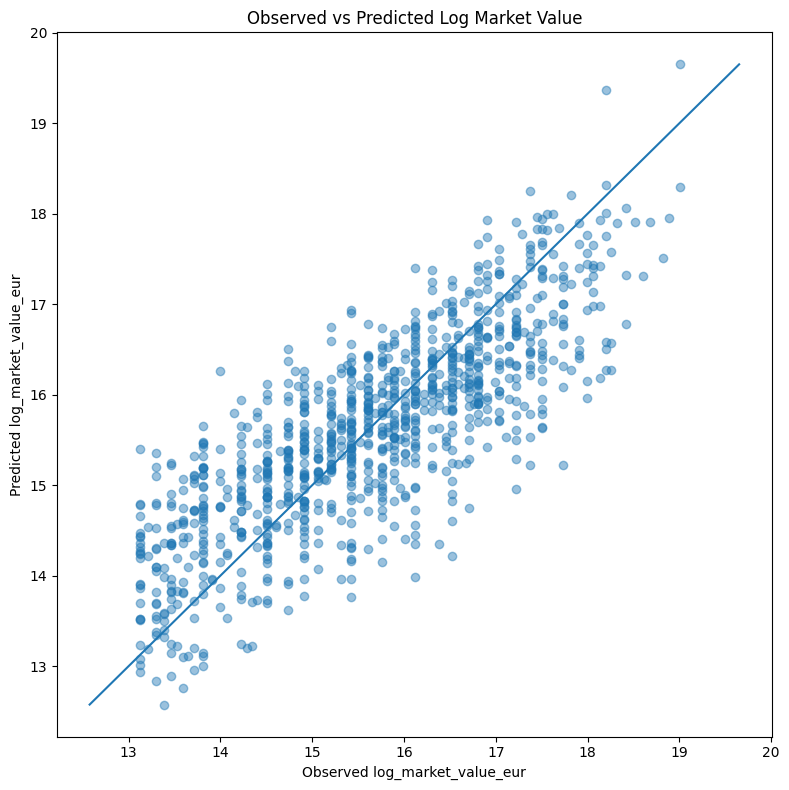

In [20]:
# Observado vs predicho
plt.figure(figsize=(8, 8))
plt.scatter(y, model_df["predicted_log_market_value"], alpha=0.45)

min_val = min(y.min(), model_df["predicted_log_market_value"].min())
max_val = max(y.max(), model_df["predicted_log_market_value"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.title("Observed vs Predicted Log Market Value")
plt.xlabel("Observed log_market_value_eur")
plt.ylabel("Predicted log_market_value_eur")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_observed_vs_predicted_log_mv.png", dpi=150)
plt.show()

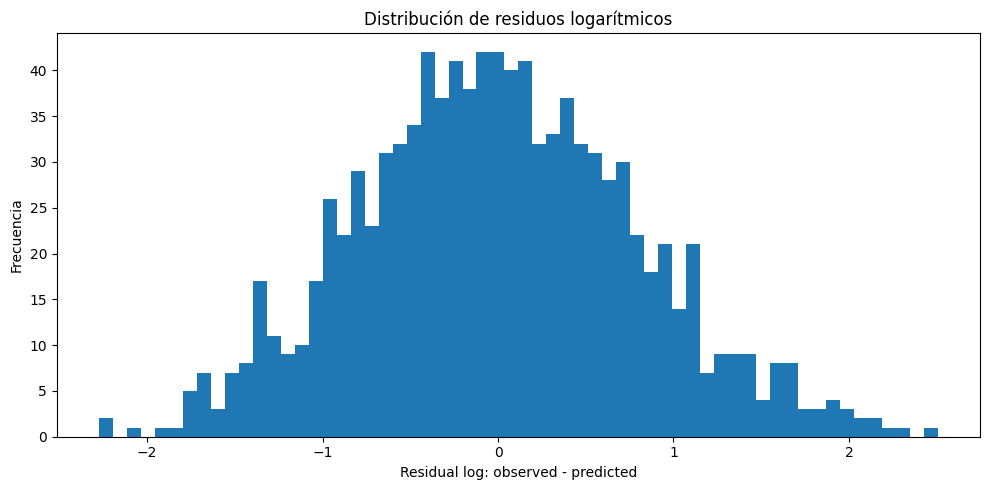

In [21]:
# Distribución de residuos
plt.figure(figsize=(10, 5))
plt.hist(model_df["residual_log"], bins=60)
plt.title("Distribución de residuos logarítmicos")
plt.xlabel("Residual log: observed - predicted")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residual_distribution.png", dpi=150)
plt.show()

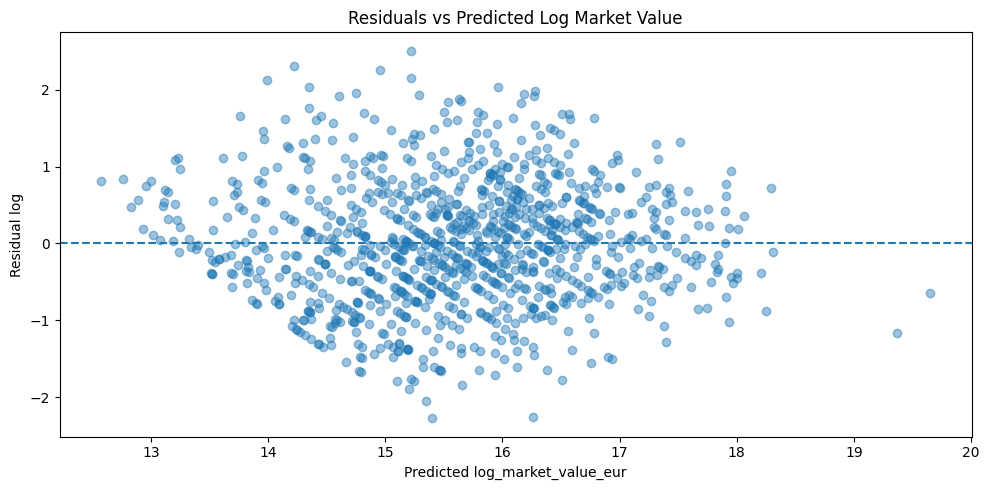

In [22]:
# Residuos vs predicción
plt.figure(figsize=(10, 5))
plt.scatter(model_df["predicted_log_market_value"], model_df["residual_log"], alpha=0.45)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Log Market Value")
plt.xlabel("Predicted log_market_value_eur")
plt.ylabel("Residual log")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residuals_vs_predicted.png", dpi=150)
plt.show()

## 14. Construcción del Inefficiency Score

El modelo genera primero el residuo econométrico clásico:

\[
\text{Residual}_{i,t} = y_{i,t}^{obs} - \hat{y}_{i,t}
\]

Donde:

- \(y_{i,t}^{obs}\) es el valor de mercado observado en escala logarítmica.
- \(\hat{y}_{i,t}\) es el valor esperado estimado por el modelo.

Con esta definición estrictamente econométrica:

- **Residual positivo:** el valor observado es superior al estimado por el modelo.
- **Residual negativo:** el valor observado es inferior al estimado por el modelo.

Sin embargo, para el objetivo de negocio del TFM interesa que el score aumente cuando el modelo estima un valor superior al observado. Por ello se define:

\[
\text{Inefficiency Score}_{i,t} = \hat{y}_{i,t} - y_{i,t}^{obs}
\]

Interpretación final utilizada en los rankings:

- **Inefficiency Score positivo:** valor esperado > valor observado → jugador potencialmente infravalorado.
- **Inefficiency Score negativo:** valor esperado < valor observado → jugador potencialmente sobrevalorado.

La misma convención se aplica al gap monetario:

\[
\text{Market Value Gap}_{i,t} = \widehat{MV}_{i,t} - MV_{i,t}^{obs}
\]

Así, un gap positivo representa una oportunidad potencial de mercado en euros.


In [23]:
# ============================================================
# 10. Inefficiency Score
# ============================================================

# Residuo econométrico clásico: observado - predicho
model_df["residual_observed_minus_predicted"] = (
    model_df[TARGET] - model_df["predicted_log_market_value"]
)

# Score de infravaloración: predicho - observado
# Positivo = el modelo estima más valor del que observa el mercado.
model_df["inefficiency_score"] = (
    model_df["predicted_log_market_value"] - model_df[TARGET]
)

# Comprobación de coherencia de signo
assert np.allclose(
    model_df["inefficiency_score"],
    -model_df["residual_observed_minus_predicted"],
)

# Versión estandarizada para facilitar comparación entre jugadores
score_mean = model_df["inefficiency_score"].mean()
score_std = model_df["inefficiency_score"].std(ddof=0)

if score_std == 0 or pd.isna(score_std):
    model_df["inefficiency_score_z"] = 0.0
else:
    model_df["inefficiency_score_z"] = (
        model_df["inefficiency_score"] - score_mean
    ) / score_std

model_df[
    [
        TARGET,
        "predicted_log_market_value",
        "residual_observed_minus_predicted",
        "inefficiency_score",
        "inefficiency_score_z",
    ]
].head()


,log_market_value_eur,predicted_log_market_value,residual_observed_minus_predicted,inefficiency_score,inefficiency_score_z
0,16.3004,17.3771,-1.0767,1.0767,1.3520
1,16.8112,17.4249,-0.6137,0.6137,0.7706
2,17.3709,17.6556,-0.2847,0.2847,0.3575
3,17.2812,17.7802,-0.4989,0.4989,0.6265
4,16.8112,17.3763,-0.5651,0.5651,0.7095


## 15. Confidence Score preliminar

Aunque el Confidence Score definitivo se desarrollará en una fase posterior, este notebook incorpora una versión preliminar basada en la calidad del matching, si la variable está disponible.

La lógica es:

- Matching más fiable → mayor confianza en el ranking.
- Matching menos fiable → la oportunidad debe revisarse manualmente antes de interpretarse como señal fuerte.

Si no existe `matching_confidence`, se asigna valor neutro igual a 1.

In [24]:
# ============================================================
# 11. Confidence Score preliminar
# ============================================================

if "matching_confidence" in model_df.columns:
    model_df["confidence_score"] = pd.to_numeric(
        model_df["matching_confidence"], errors="coerce"
    ).fillna(0.5)
else:
    model_df["confidence_score"] = 1.0

# Opportunity Score simple: infravaloración ajustada por confianza
model_df["opportunity_score"] = (
    model_df["inefficiency_score_z"] * model_df["confidence_score"]
)

model_df[["inefficiency_score_z", "confidence_score", "opportunity_score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
inefficiency_score_z,"1,012.0000",0.0000,1.0005,-3.1494,-0.6695,0.0353,0.6924,2.8569
confidence_score,"1,012.0000",0.9996,0.0042,0.9286,1.0000,1.0000,1.0000,1.0000
opportunity_score,"1,012.0000",-0.0000,1.0001,-3.1494,-0.6695,0.0353,0.6913,2.8569


## 16. Rankings finales

Se generan dos rankings:

1. **Jugadores potencialmente infravalorados:** mayor `opportunity_score`, `inefficiency_score` positivo y, cuando existe valor en euros, `market_value_gap_eur` positivo.
2. **Jugadores potencialmente sobrevalorados:** menor `opportunity_score`, `inefficiency_score` negativo y, cuando existe valor en euros, `market_value_gap_eur` negativo.

La convención de signos queda alineada con negocio:

- `market_value_gap_eur = predicted_market_value_eur - market_value_eur`
- `market_value_gap_pct = market_value_gap_eur / market_value_eur`

Por tanto, un gap positivo indica que el modelo estima un valor superior al observado por Transfermarkt. Estos rankings no deben interpretarse como decisiones automáticas de fichaje, sino como una herramienta de priorización para análisis experto posterior.


In [25]:
# ============================================================
# 12. Rankings
# ============================================================

ranking_columns = [
    col for col in [
        "player_id",
        "player_name",
        "club",
        "league",
        "season",
        "position_group",
        "age",
        "market_value_eur",
        "predicted_market_value_eur",
        "market_value_gap_eur",
        "market_value_gap_pct",
        "log_market_value_eur",
        "predicted_log_market_value",
        "inefficiency_score",
        "inefficiency_score_z",
        "confidence_score",
        "opportunity_score",
        "matching_method",
        "age_diff",
        "club_score",
    ] if col in model_df.columns
]

undervalued_ranking = (
    model_df
    .sort_values("opportunity_score", ascending=False)
    [ranking_columns]
    .head(50)
    .copy()
)

overvalued_ranking = (
    model_df
    .sort_values("opportunity_score", ascending=True)
    [ranking_columns]
    .head(50)
    .copy()
)

undervalued_ranking.head(20)

,club,league,season,position_group,age,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,age_diff,club_score
264,Paços de Ferreira,Liga Portugal,2022-2023,DEF,22.3000,"500,000.0000","4,865,195.7613","4,365,195.7613",8.7304,13.1224,15.3976,2.2753,2.8569,1.0000,2.8569,exact_age_club_validated,1.3000,91.8919
245,Norwich City,Premier League,2021-2022,DEF,20.0000,"1,200,000.0000","11,545,232.2257","10,345,232.2257",8.6210,13.9978,16.2618,2.2640,2.8427,1.0000,2.8427,exact_age_club_validated,1.0000,100.0000
513,Boavista,Liga Portugal,2020-2021,DEF,21.9000,"600,000.0000","4,646,782.8986","4,046,782.8986",6.7446,13.3047,15.3517,2.0470,2.5703,1.0000,2.5703,exact_age_club_validated,0.9000,84.2105
876,Eibar,LaLiga,2020-2021,MID,22.0000,"600,000.0000","4,016,285.1401","3,416,285.1401",5.6938,13.3047,15.2059,1.9012,2.3872,1.0000,2.3872,exact_age_club_validated,1.0000,76.9231
794,Getafe,LaLiga,2023-2024,MID,20.0000,"1,000,000.0000","6,313,154.5118","5,313,154.5118",5.3132,13.8155,15.6581,1.8426,2.3137,1.0000,2.3137,exact_age_club_validated,1.0000,80.0000
705,Schalke 04,Bundesliga,2022-2023,MID,22.5000,"600,000.0000","3,604,847.7569","3,004,847.7569",5.0081,13.3047,15.0978,1.7931,2.2515,1.0000,2.2515,exact_age_club_validated,1.5000,82.3529
1002,Schalke 04,Bundesliga,2020-2021,MID,21.1000,"700,000.0000","4,192,172.7014","3,492,172.7014",4.9888,13.4588,15.2487,1.7899,2.2475,1.0000,2.2475,exact_age_club_validated,1.1000,70.0000
736,Stuttgart,Bundesliga,2022-2023,ATT,22.3000,"2,500,000.0000","14,759,219.2392","12,259,219.2392",4.9037,14.7318,16.5074,1.7756,2.2295,1.0000,2.2295,exact_age_club_validated,1.3000,81.8182
266,Paços de Ferreira,Liga Portugal,2022-2023,ATT,22.4000,"700,000.0000","4,067,227.7657","3,367,227.7657",4.8103,13.4588,15.2185,1.7596,2.2095,1.0000,2.2095,exact_age_club_validated,1.4000,91.8919
615,Levante,LaLiga,2020-2021,ATT,22.9000,"1,500,000.0000","8,364,212.6645","6,864,212.6645",4.5761,14.2210,15.9395,1.7185,2.1578,1.0000,2.1578,exact_age_club_validated,0.9000,82.3529


In [26]:
overvalued_ranking.head(20)

,club,league,season,position_group,age,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,age_diff,club_score
52,Sporting CP,Liga Portugal,2022-2023,MID,22.2000,"50,000,000.0000","4,070,877.1367","-45,929,122.8633",-0.9186,17.7275,15.2194,-2.5082,-3.1494,1.0000,-3.1494,exact_age_club_validated,1.2000,100.0000
874,Braga,Liga Portugal,2021-2022,DEF,22.9000,"15,000,000.0000","1,495,786.7464","-13,504,213.2536",-0.9003,16.5236,14.2182,-2.3054,-2.8948,1.0000,-2.8948,exact_age_club_validated,0.9000,76.9231
229,Bayern Munich,Bundesliga,2022-2023,MID,21.1000,"30,000,000.0000","3,135,203.4780","-26,864,796.5220",-0.8955,17.2167,14.9582,-2.2585,-2.8359,1.0000,-2.8359,exact_age_club_validated,1.1000,100.0000
213,RB Leipzig,Bundesliga,2020-2021,DEF,22.0000,"35,000,000.0000","4,075,119.1307","-30,924,880.8693",-0.8836,17.3709,15.2204,-2.1504,-2.7002,1.0000,-2.7002,exact_age_club_validated,1.0000,100.0000
885,Porto,Liga Portugal,2020-2021,DEF,22.3000,"10,000,000.0000","1,190,809.7531","-8,809,190.2469",-0.8809,16.1181,13.9901,-2.1280,-2.6719,1.0000,-2.6719,exact_age_club_validated,1.3000,76.9231
133,Real Madrid,LaLiga,2020-2021,MID,22.9000,"65,000,000.0000","8,526,661.5150","-56,473,338.4850",-0.8688,17.9899,15.9587,-2.0312,-2.5504,1.0000,-2.5504,exact_age_club_validated,0.9000,100.0000
682,Benfica,Liga Portugal,2022-2023,DEF,22.0000,"13,000,000.0000","1,706,475.7506","-11,293,524.2494",-0.8687,16.3805,14.3499,-2.0305,-2.5496,1.0000,-2.5496,exact_age_club_validated,1.0000,82.3529
516,Juventus,Serie A,2021-2022,ATT,22.4000,"85,000,000.0000","11,712,564.9572","-73,287,435.0428",-0.8622,18.2582,16.2762,-1.9820,-2.4887,1.0000,-2.4887,exact_age_club_validated,1.4000,84.2105
806,Monaco,Ligue 1,2020-2021,MID,22.3000,"18,000,000.0000","2,539,944.9330","-15,460,055.0670",-0.8589,16.7059,14.7477,-1.9582,-2.4588,1.0000,-2.4588,exact_age_club_validated,1.3000,80.0000
63,RB Leipzig,Bundesliga,2022-2023,DEF,21.4000,"75,000,000.0000","10,658,578.0805","-64,341,421.9195",-0.8579,18.1330,16.1819,-1.9511,-2.4499,1.0000,-2.4499,exact_age_club_validated,1.4000,100.0000


In [27]:
# Exportación de rankings y dataset con scores
undervalued_ranking.to_csv(OUTPUT_DIR / "03_undervalued_ranking.csv", index=False)
overvalued_ranking.to_csv(OUTPUT_DIR / "03_overvalued_ranking.csv", index=False)
model_df.to_parquet(OUTPUT_DIR / "03_player_season_with_inefficiency_scores.parquet", index=False)

print(f"Ranking undervalued exportado a: {OUTPUT_DIR / '03_undervalued_ranking.csv'}")
print(f"Ranking overvalued exportado a: {OUTPUT_DIR / '03_overvalued_ranking.csv'}")
print(f"Dataset con scores exportado a: {OUTPUT_DIR / '03_player_season_with_inefficiency_scores.parquet'}")

Ranking undervalued exportado a: c:\Users\manue\Projects\market-value-football-tfm\reports\tables\03_undervalued_ranking.csv
Ranking overvalued exportado a: c:\Users\manue\Projects\market-value-football-tfm\reports\tables\03_overvalued_ranking.csv
Dataset con scores exportado a: c:\Users\manue\Projects\market-value-football-tfm\reports\tables\03_player_season_with_inefficiency_scores.parquet


## 17. Análisis agregado del Inefficiency Score

Este análisis permite comprobar si el score está sesgado sistemáticamente por liga o posición. Si una liga completa aparece como infravalorada o sobrevalorada, podría indicar que el modelo todavía no captura adecuadamente diferencias estructurales del mercado.

In [28]:
# Inefficiency por liga
if "league" in model_df.columns:
    league_score = (
        model_df
        .groupby("league", dropna=False)
        .agg(
            n_players=("inefficiency_score", "size"),
            mean_inefficiency=("inefficiency_score", "mean"),
            median_inefficiency=("inefficiency_score", "median"),
            mean_opportunity=("opportunity_score", "mean"),
        )
        .sort_values("mean_opportunity", ascending=False)
    )
    display(league_score)

,n_players,mean_inefficiency,median_inefficiency,mean_opportunity
league,,,,
Premier League,143,-0.0000,-0.0682,0.0010
Bundesliga,159,-0.0000,0.0111,0.0000
Liga Portugal,129,-0.0000,0.1431,0.0000
Ligue 1,140,-0.0000,0.0948,-0.0000
Eredivisie,153,-0.0000,0.0389,-0.0000
LaLiga,130,-0.0000,-0.0049,-0.0001
Serie A,158,-0.0000,0.0189,-0.0008


In [29]:
# Inefficiency por posición
if "position_group" in model_df.columns:
    position_score = (
        model_df
        .groupby("position_group", dropna=False)
        .agg(
            n_players=("inefficiency_score", "size"),
            mean_inefficiency=("inefficiency_score", "mean"),
            median_inefficiency=("inefficiency_score", "median"),
            mean_opportunity=("opportunity_score", "mean"),
        )
        .sort_values("mean_opportunity", ascending=False)
    )
    display(position_score)

,n_players,mean_inefficiency,median_inefficiency,mean_opportunity
position_group,,,,
ATT,336,-0.0000,0.0299,0.0002
GK,30,-0.0000,0.0829,-0.0000
MID,325,-0.0000,0.0517,-0.0001
DEF,321,-0.0000,0.0221,-0.0001


## 18. Interpretación de negocio

El modelo permite traducir una estimación econométrica en un output accionable para scouting:

- El valor esperado estimado representa cuánto debería valer un jugador según su rendimiento, edad y contexto competitivo.
- La diferencia entre valor esperado y valor observado permite detectar posibles ineficiencias.
- Un `inefficiency_score` positivo indica que el modelo estima un valor superior al observado: potencial infravaloración.
- Un `market_value_gap_eur` positivo cuantifica esa posible infravaloración en euros.
- El ranking prioriza jugadores que el modelo considera más valiosos de lo que refleja su valor actual.

Desde la perspectiva de un club, este output puede utilizarse como una primera capa de filtrado para:

- reducir el universo de jugadores a analizar;
- identificar targets de seguimiento;
- comparar jugadores entre ligas;
- complementar informes cualitativos de scouting;
- priorizar oportunidades en ventanas de fichajes.

El modelo no sustituye al criterio experto. Su función es mejorar la eficiencia del proceso de identificación inicial de oportunidades.


## 18. Conclusiones del modelo econométrico

El modelo OLS con efectos fijos por liga, temporada y posición presenta un rendimiento explicativo razonablemente sólido para un modelo econométrico interpretable. Sobre una muestra final de **1.012 observaciones** y **17 variables explicativas**, el modelo alcanza un **R² de 0,648** y un **R² ajustado de 0,642**, lo que indica que aproximadamente el 64% de la variabilidad del logaritmo del valor de mercado queda explicada por las variables incluidas.

Desde el punto de vista predictivo, el modelo obtiene un **MAE logarítmico de 0,636** y un **RMSE logarítmico de 0,796**. Estos errores son aceptables teniendo en cuenta la elevada dispersión del valor de mercado en fútbol profesional, la naturaleza parcialmente subjetiva de Transfermarkt y la especificación deliberadamente parsimoniosa del modelo.

Los coeficientes principales son coherentes con la lógica económica del mercado. Los minutos jugados presentan un efecto positivo y estadísticamente significativo, lo que sugiere que la exposición competitiva es un determinante relevante del valor de mercado. Asimismo, los goles por 90 y las asistencias por 90 muestran coeficientes positivos, elevados y significativos, reflejando la prima que el mercado asigna a la producción ofensiva. La edad presenta un coeficiente negativo, lo que es consistente con el enfoque del dataset hacia jugadores jóvenes: dentro del rango analizado, menor edad implica mayor potencial futuro y, por tanto, mayor valoración esperada, manteniendo constantes el resto de factores.

Los efectos fijos capturan diferencias estructurales importantes entre competiciones. La Premier League presenta un coeficiente positivo significativo, coherente con su mayor capacidad económica y exposición mediática. En cambio, Eredivisie y Liga Portugal muestran coeficientes negativos relevantes, lo que indica que, a igualdad de rendimiento, edad, temporada y posición, los jugadores de estas ligas tienden a presentar valores de mercado inferiores respecto a la categoría base. Este resultado es especialmente relevante desde una perspectiva de scouting, ya que estas competiciones pueden contener oportunidades de mercado relativamente más atractivas.

El diagnóstico de multicolinealidad muestra valores de VIF generalmente aceptables. La mayoría de variables se sitúan por debajo de 5, lo que descarta problemas severos de multicolinealidad. La edad presenta un VIF más elevado, de aproximadamente 17,8, probablemente debido a su relación con la progresión de carrera, la posición y determinadas estructuras de liga o temporada. No obstante, dado que la edad es una variable teóricamente esencial en la valoración de jugadores, se mantiene en el modelo por su relevancia económica y deportiva.

El condition number es elevado, superior a 31.000, lo que puede estar asociado tanto a diferencias de escala entre variables como a cierta dependencia lineal parcial derivada de las variables dummy. Por este motivo, los resultados deben interpretarse con cautela y se justifica el uso de errores estándar robustos HC3.

El análisis gráfico muestra una relación positiva clara entre valores observados y predichos en escala logarítmica. La nube de puntos sigue razonablemente la diagonal, aunque con dispersión relevante en los extremos. La distribución de residuos es aproximadamente centrada en cero, lo que sugiere ausencia de sesgo sistemático fuerte. El gráfico de residuos frente a predicciones no muestra un patrón estructural extremo, aunque sí cierta heterogeneidad, esperable en un mercado tan disperso como el fútbol profesional.

## 19. Conclusión sobre el Inefficiency Score

El Inefficiency Score se define como la diferencia entre el valor esperado estimado por el modelo y el valor observado de mercado. Por tanto, valores positivos indican que el jugador presenta un valor estimado superior al valor registrado en Transfermarkt, lo que se interpreta como una posible infravaloración.

Los rankings generados identifican jugadores cuyo valor esperado es muy superior al observado. En estos casos, el modelo detecta perfiles jóvenes, con rendimiento suficiente y bajo valor de mercado relativo, especialmente en clubes y ligas de menor exposición. Estos jugadores representan candidatos iniciales para análisis de scouting más profundo.

Por el contrario, los jugadores con Inefficiency Score negativo aparecen como perfiles cuyo valor observado supera ampliamente el valor estimado por el modelo. En muchos casos pertenecen a clubes de alto prestigio o entornos de fuerte exposición mediática, como Real Madrid, PSG, Bayern, Juventus, Barcelona, RB Leipzig o Sporting CP. Esto sugiere que el modelo está capturando parcialmente una prima de reputación, club, narrativa de mercado o potencial percibido que no queda completamente explicada por las variables deportivas incluidas.

## 20. Interpretación de negocio

Desde una perspectiva aplicada, el modelo no debe entenderse como una herramienta automática de decisión de fichajes, sino como un sistema de priorización cuantitativa. Su principal utilidad es reducir el universo de búsqueda y generar una primera lista de jugadores potencialmente infravalorados que puedan ser revisados posteriormente por scouts, analistas de vídeo y dirección deportiva.

El modelo aporta valor en tres niveles:

1. Estima un valor esperado de mercado ajustado por rendimiento, edad, liga, temporada y posición.
2. Detecta discrepancias entre valor observado y valor esperado.
3. Ordena jugadores mediante un Opportunity Score que combina infravaloración y confianza del matching.

En términos de estrategia deportiva, los resultados son coherentes con una lógica de inversión tipo buy low, sell high. Las ligas con coeficientes negativos, como Eredivisie y Liga Portugal, pueden contener jugadores cuyo rendimiento no está plenamente capitalizado en el valor de mercado, lo que refuerza su interés como mercados de prospección.

## 21. Limitaciones

El modelo presenta varias limitaciones relevantes. En primer lugar, la muestra final utilizada para la estimación es de 1.012 observaciones, inferior al dataset completo disponible, debido a la eliminación de registros incompletos y a las restricciones de modelado. En segundo lugar, el modelo actual solo incorpora variables básicas de rendimiento: minutos, goles, asistencias y edad. Esto deja fuera dimensiones clave como calidad de ocasiones, progresión de balón, rendimiento defensivo, nivel del equipo, duración contractual, internacionalidades, lesiones o salario.

Además, el valor de mercado de Transfermarkt no es una variable puramente objetiva, sino una estimación influida por percepción, reputación, narrativa mediática, club de pertenencia y expectativas futuras. Por ello, parte de los residuos puede reflejar variables omitidas y no necesariamente ineficiencias reales.

También debe considerarse que el modelo es estimado in-sample. Para validar su capacidad real de generalización será necesario aplicar una evaluación out-of-sample, preferiblemente con validación temporal.

## 22. Próximos pasos recomendados

El siguiente paso metodológico debería ser ampliar el modelo con variables avanzadas de rendimiento, especialmente xG, xA, métricas de progresión, creación de tiro y contribución defensiva. Después, conviene construir una versión con validación temporal, entrenando con temporadas anteriores y evaluando sobre temporadas posteriores.

También sería recomendable comparar este modelo econométrico con modelos de machine learning supervisado, como Random Forest, XGBoost o LightGBM, para evaluar si capturan relaciones no lineales y mejoran la capacidad predictiva. La narrativa final del TFM debería presentar este modelo OLS como el modelo interpretable de referencia y los modelos ML como una extensión orientada a performance predictiva.
